Name : Venkatesh Paitwar

Branch : CSE(DS)

Batch : C4-62

NLP LAB - 08

In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

In [ ]:
import re, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

for pkg in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# STAGE 1 – DATASET LOADING AND EXPLORATION


In [ ]:
df = pd.read_csv("IMDB Dataset.csv")
df.columns = ['review', 'sentiment']

print("Shape          :", df.shape)
print("Sentiment counts:\n", df['sentiment'].value_counts())
print("Missing values :", df.isnull().sum().sum())


Shape          : (50000, 2)
Sentiment counts:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Missing values : 0


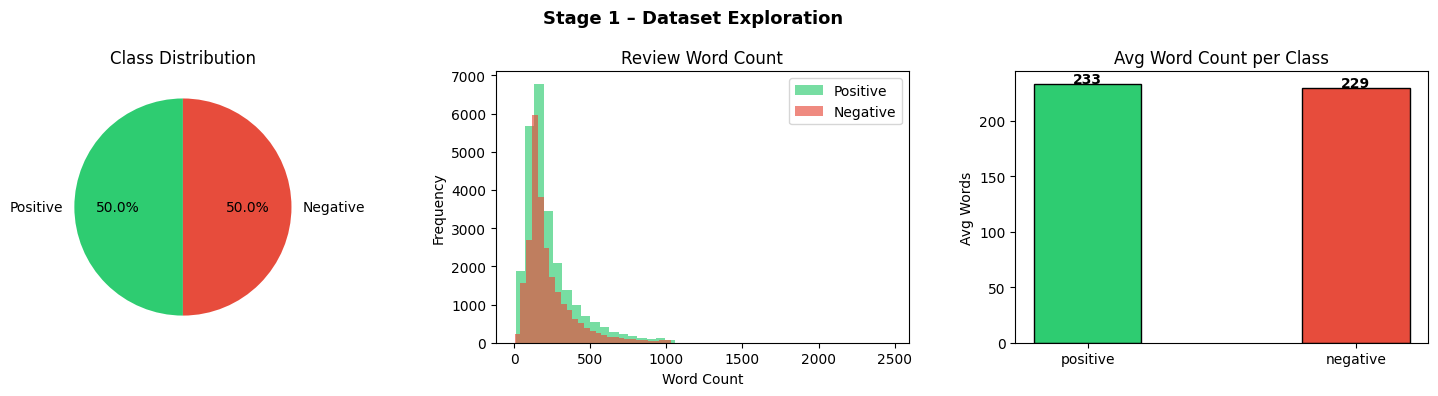

In [ ]:
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Stage 1 – Dataset Exploration", fontsize=13, fontweight='bold')

# Plot 1: Class balance
df['sentiment'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    labels=['Positive', 'Negative'], startangle=90
)
axes[0].set_ylabel("")
axes[0].set_title("Class Distribution")

# Plot 2: Word count histogram
for s, c in [('positive', '#2ecc71'), ('negative', '#e74c3c')]:
    axes[1].hist(df[df['sentiment'] == s]['word_count'],
                 bins=40, alpha=0.65, color=c, label=s.capitalize())
axes[1].set_title("Review Word Count")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Plot 3: Avg word count per class
avg = df.groupby('sentiment')['word_count'].mean().sort_index(ascending=False)
bars = axes[2].bar(avg.index, avg.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.4)
axes[2].set_title("Avg Word Count per Class")
axes[2].set_ylabel("Avg Words")
for bar, val in zip(bars, avg.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 val + 1, f'{val:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("eda_plot.png", dpi=120, bbox_inches='tight')
plt.show()

# STAGE 2 – TEXT PREPROCESSING


In [ ]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))
# Keep negation words — they carry sentiment meaning
STOP_WORDS -= {'no', 'not', 'nor', 'never', "don't", "doesn't",
               "didn't", "won't", "wouldn't", "couldn't", "isn't"}

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)      # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

print("Preprocessing reviews …")
df['clean']  = df['review'].apply(preprocess)
df['label']  = (df['sentiment'] == 'positive').astype(int)

print(f"Avg words BEFORE : {df['word_count'].mean():.0f}")
print(f"Avg tokens AFTER : {df['clean'].apply(lambda x: len(x.split())).mean():.0f}")
print("\n[Before]", df['review'].iloc[0][:200])
print("\n[After] ", df['clean'].iloc[0][:200])

Preprocessing reviews …
Avg words BEFORE : 231
Avg tokens AFTER : 118

[Before] One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

[After]  one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust not show faint hearted timid show pull punch regard d


# STAGE 3 – FEATURE EXTRACTION  (TF-IDF and Bag of Words)


In [ ]:
X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")

# TF-IDF vectorizer  (primary)
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                        min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Bag-of-Words vectorizer  (comparison)
bow = CountVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

print(f"\nTF-IDF matrix shape : {X_train_tfidf.shape}")
print(f"BoW    matrix shape : {X_train_bow.shape}")
print(f"Vocabulary size     : {len(tfidf.vocabulary_):,}")

Train : 40,000  |  Test : 10,000

TF-IDF matrix shape : (40000, 20000)
BoW    matrix shape : (40000, 20000)
Vocabulary size     : 20,000


# STAGE 4 – TRAINING MULTIPLE CLASSIFICATION MODELS


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                    random_state=42),
}

In [ ]:
results     = {}
trained_mdl = {}

print(f"\n{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("─" * 62)

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec  = recall_score(y_test, y_pred) * 100
    f1   = f1_score(y_test, y_pred) * 100

    results[name]     = dict(Accuracy=round(acc,2), Precision=round(prec,2),
                              Recall=round(rec,2), F1=round(f1,2))
    trained_mdl[name] = model
    flag = " ✅" if acc >= 90 else ""
    print(f"{name:<22} {acc:>8.2f}% {prec:>9.2f}% {rec:>7.2f}% {f1:>7.2f}%{flag}")


Model                   Accuracy  Precision   Recall       F1
──────────────────────────────────────────────────────────────
Logistic Regression       90.41%     89.56%   91.48%   90.51% ✅
Naive Bayes               87.81%     86.73%   89.28%   87.99%
Linear SVM                90.38%     90.11%   90.72%   90.41% ✅
Decision Tree             74.48%     72.34%   79.28%   75.65%
Random Forest             86.31%     86.48%   86.08%   86.28%


# STAGE 5 – PERFORMANCE EVALUATION AND MODEL COMPARISON


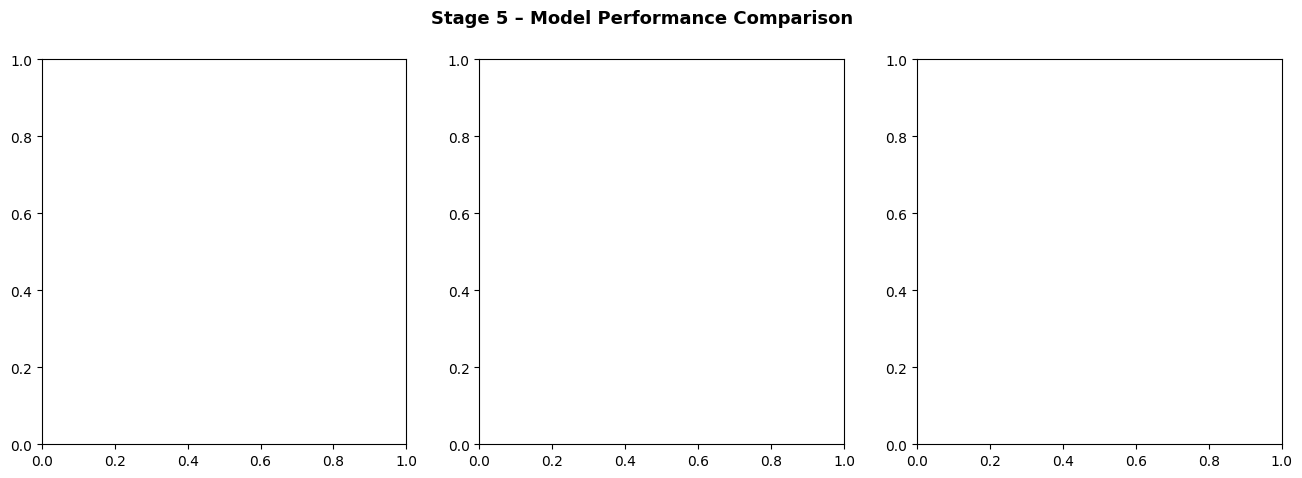

In [ ]:
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Stage 5 – Model Performance Comparison", fontsize=13, fontweight='bold')

pal   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
names = [n.replace(' ', '\n') for n in results_df.index]

In [ ]:
# Plot 1: Accuracy bar chart
bars = axes[0].bar(names, results_df['Accuracy'], color=pal, edgecolor='black')
axes[0].axhline(90, color='red', ls='--', lw=1.5, label='90% line')
axes[0].set_title("Test Accuracy (%)")
axes[0].set_ylim(60, 105)
axes[0].legend(fontsize=9)
for bar, v in zip(bars, results_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')

In [ ]:
# Plot 2: Grouped metrics
x = np.arange(len(results_df))
w = 0.18
for i, (met, col) in enumerate(zip(['Accuracy','Precision','Recall','F1'],
                                    ['#3498db','#2ecc71','#e74c3c','#f39c12'])):
    axes[1].bar(x + i*w, results_df[met], w, label=met, color=col, edgecolor='black')
axes[1].set_xticks(x + w*1.5)
axes[1].set_xticklabels(names, fontsize=8)
axes[1].set_title("All Metrics")
axes[1].set_ylim(60, 108)
axes[1].legend(fontsize=8)

In [ ]:
# Plot 3: F1 horizontal bar
axes[2].barh(names[::-1], results_df['F1'].values[::-1],
             color=pal[::-1], edgecolor='black')
axes[2].axvline(90, color='red', ls='--', lw=1.5)
axes[2].set_title("F1-Score Ranking")
axes[2].set_xlabel("F1 (%)")
for i, v in enumerate(results_df['F1'].values[::-1]):
    axes[2].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Full Results Table:")
print(results_df.to_string())

<Figure size 640x480 with 0 Axes>


📊 Full Results Table:
                     Accuracy  Precision  Recall     F1
Logistic Regression     90.41      89.56   91.48  90.51
Linear SVM              90.38      90.11   90.72  90.41
Naive Bayes             87.81      86.73   89.28  87.99
Random Forest           86.31      86.48   86.08  86.28
Decision Tree           74.48      72.34   79.28  75.65


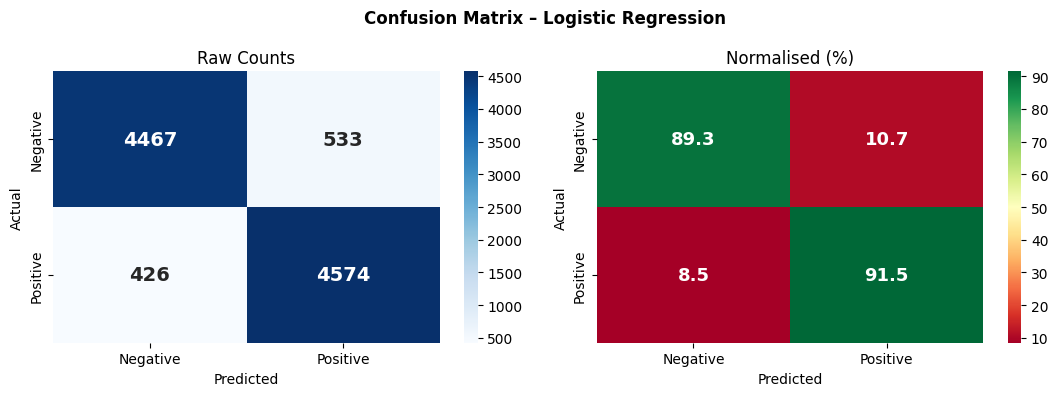

In [ ]:
best_name  = results_df['Accuracy'].idxmax()
best_model = trained_mdl[best_name]
y_pred_best = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f"Confusion Matrix – {best_name}", fontsize=12, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'],
            annot_kws={"size":14,"weight":"bold"})
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

cm_pct = cm.astype(float) / cm.sum(axis=1)[:,None] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'],
            annot_kws={"size":13,"weight":"bold"})
axes[1].set_title("Normalised (%)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

# STAGE 6 – BEST MODEL SELECTION


In [ ]:
print(f"\n Best Model  : {best_name}")
print(f"   Accuracy   : {results_df.loc[best_name,'Accuracy']}%")
print(f"   Precision  : {results_df.loc[best_name,'Precision']}%")
print(f"   Recall     : {results_df.loc[best_name,'Recall']}%")
print(f"   F1-Score   : {results_df.loc[best_name,'F1']}%")


 Best Model  : Logistic Regression
   Accuracy   : 90.41%
   Precision  : 89.56%
   Recall     : 91.48%
   F1-Score   : 90.51%


In [ ]:

print(f"\n Classification Report:\n")
print(classification_report(y_test, y_pred_best,
                              target_names=['Negative','Positive']))


 Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.90      0.91      0.91      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf,      'tfidf_vectorizer.pkl')
print("Model saved : sentiment_model.pkl")
print("Vectorizer  : tfidf_vectorizer.pkl")

Model saved : sentiment_model.pkl
Vectorizer  : tfidf_vectorizer.pkl


In [ ]:
def predict(text):
    clean = preprocess(text)
    vec   = tfidf.transform([clean])
    pred  = best_model.predict(vec)[0]
    return "Positive 😊" if pred == 1 else "Negative 😡"

print("\n Sample Predictions:")
print(predict("Amazing film! Loved every minute of it."))
print(predict("Terrible movie. Complete waste of time."))


 Sample Predictions:
Positive 😊
Negative 😡


# Streamlit GUI Representation

In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.5 MB/s eta 0:00:00


In [10]:
app_code = """
import streamlit as st
import joblib, re, numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for p in ['stopwords','wordnet','omw-1.4']:
    nltk.download(p, quiet=True)

st.set_page_config(page_title="Movie Sentiment Analyzer", page_icon="🎬", layout="wide")

st.markdown('''
<style>
.title  { text-align:center; font-size:2.4rem; font-weight:800; color:#1e293b; }
.sub    { text-align:center; color:#64748b; font-size:1rem; margin-bottom:1rem; }
.pos-box{ background:#dcfce7; border:2px solid #16a34a; border-radius:12px;
          padding:1.2rem; text-align:center; font-size:1.5rem;
          font-weight:800; color:#15803d; margin:0.5rem 0; }
.neg-box{ background:#fee2e2; border:2px solid #dc2626; border-radius:12px;
          padding:1.2rem; text-align:center; font-size:1.5rem;
          font-weight:800; color:#b91c1c; margin:0.5rem 0; }
.stat   { background:#f1f5f9; border-radius:10px; padding:1rem;
          text-align:center; border:1px solid #e2e8f0; }
.snum   { font-size:1.6rem; font-weight:800; color:#1e293b; }
.slbl   { font-size:0.75rem; color:#64748b; text-transform:uppercase; }
</style>
''', unsafe_allow_html=True)

@st.cache_resource
def load_all():
    model = joblib.load("sentiment_model.pkl")
    vec   = joblib.load("tfidf_vectorizer.pkl")
    lem   = WordNetLemmatizer()
    sw    = set(stopwords.words("english")) - {"no","not","never","nor","don't","doesn't"}
    return model, vec, lem, sw

model, vectorizer, lem, sw = load_all()

def clean(text):
    text = re.sub(r"<[^>]+>"," ", str(text).lower())
    text = re.sub(r"[^a-z\s]"," ", text)
    return " ".join([lem.lemmatize(w) for w in text.split()
                     if w not in sw and len(w) > 2])

# ── Sidebar ──────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🎬 About")
    st.markdown("---")
    st.markdown("**Dataset:** IMDB 50K Reviews")
    st.markdown("**Task:** Binary Sentiment Classification")
    st.markdown("**Features:** TF-IDF (unigrams + bigrams)")
    st.markdown("---")
    st.markdown("## 📋 Pipeline Stages")
    stages = [
        "1. Dataset Loading & EDA",
        "2. Text Preprocessing",
        "3. Feature Extraction",
        "4. Train Multiple Models",
        "5. Performance Evaluation",
        "6. Best Model Selection",
        "7. GUI Implementation"
    ]
    for s in stages:
        st.markdown(f"✅ {s}")
    st.markdown("---")
    st.markdown("## 🤖 Models Trained")
    for m in ["Logistic Regression","Naive Bayes",
              "Linear SVM","Decision Tree","Random Forest"]:
        st.markdown(f"• {m}")

# ── Main ─────────────────────────────────────────────────────
st.markdown("<p class='title'>🎬 Movie Review Sentiment Analyzer</p>", unsafe_allow_html=True)
st.markdown("<p class='sub'>AI-powered NLP system to detect Positive or Negative movie reviews</p>", unsafe_allow_html=True)
st.markdown("---")

col_input, col_result = st.columns([1.2, 1], gap="large")

with col_input:
    st.subheader("✍️ Enter Your Review")
    review = st.text_area("", height=200,
        placeholder="e.g. This movie was absolutely brilliant. The acting was superb...")

    predict_btn = st.button("🔍 Predict Sentiment", use_container_width=True)

    st.markdown("#### 💡 Try these examples:")
    examples = {
        "⭐ Positive": "This movie was absolutely fantastic! The acting was superb and the story was deeply moving.",
        "👎 Negative": "Terrible film. Complete waste of time. The plot made no sense and acting was awful.",
        "😐 Mixed":    "Not bad but not great either. Some good moments but mostly forgettable."
    }
    for label, text in examples.items():
        if st.button(label, use_container_width=True):
            st.session_state["example"] = text
            st.rerun()

    if "example" in st.session_state:
        review = st.session_state.pop("example")

with col_result:
    st.subheader("🎯 Prediction Result")

    if predict_btn and review.strip():
        cleaned   = clean(review)
        vec_input = vectorizer.transform([cleaned])
        pred      = model.predict(vec_input)[0]

        if pred == 1:
            st.markdown("<div class='pos-box'>😊 Positive Review</div>",
                        unsafe_allow_html=True)
        else:
            st.markdown("<div class='neg-box'>😡 Negative Review</div>",
                        unsafe_allow_html=True)

        try:
            score = model.decision_function(vec_input)[0]
            conf  = min(round(abs(score) * 12, 1), 99.9)
        except:
            conf  = round(max(model.predict_proba(vec_input)[0]) * 100, 1)

        st.markdown(f"**Confidence:** `{conf}%`")
        st.progress(min(conf / 100, 1.0))
        st.markdown("---")

        st.subheader("📊 Review Statistics")
        words = review.split()
        c1, c2 = st.columns(2)
        c3, c4 = st.columns(2)
        c1.markdown(f"<div class='stat'><div class='snum'>{len(words)}</div><div class='slbl'>Total Words</div></div>", unsafe_allow_html=True)
        c2.markdown(f"<div class='stat'><div class='snum'>{len(review)}</div><div class='slbl'>Characters</div></div>", unsafe_allow_html=True)
        c3.markdown(f"<div class='stat'><div class='snum'>{len(cleaned.split())}</div><div class='slbl'>Tokens (processed)</div></div>", unsafe_allow_html=True)
        avg = round(np.mean([len(w) for w in words]), 1) if words else 0
        c4.markdown(f"<div class='stat'><div class='snum'>{avg}</div><div class='slbl'>Avg Word Length</div></div>", unsafe_allow_html=True)

        with st.expander("🔬 Preprocessed Text"):
            st.code(cleaned)

    elif predict_btn:
        st.warning("⚠️ Please enter a review first.")
    else:
        st.info("👈 Enter a review on the left and click **Predict Sentiment**")

st.markdown("---")
st.markdown("<p style='text-align:center;color:#94a3b8;font-size:0.8rem;'>Movie Review Sentiment Analysis | NLP Project | Streamlit GUI</p>", unsafe_allow_html=True)
"""

with open("app.py", "w") as f:
    f.write(app_code)
print("✅ app.py updated!")

✅ app.py updated!


<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_26500/2279012526.py:42: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub(r"[^a-z\s]"," ", text)


In [11]:
import subprocess, time
from pyngrok import ngrok

# Kill old process
subprocess.run(["pkill", "-f", "streamlit"])
time.sleep(3)

# Restart
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])
time.sleep(6)

ngrok.kill()
url = ngrok.connect(8501)
print("✅ Open this:", url)

✅ Open this: NgrokTunnel: "https://libratory-johana-irrelative.ngrok-free.dev" -> "http://localhost:8501"
